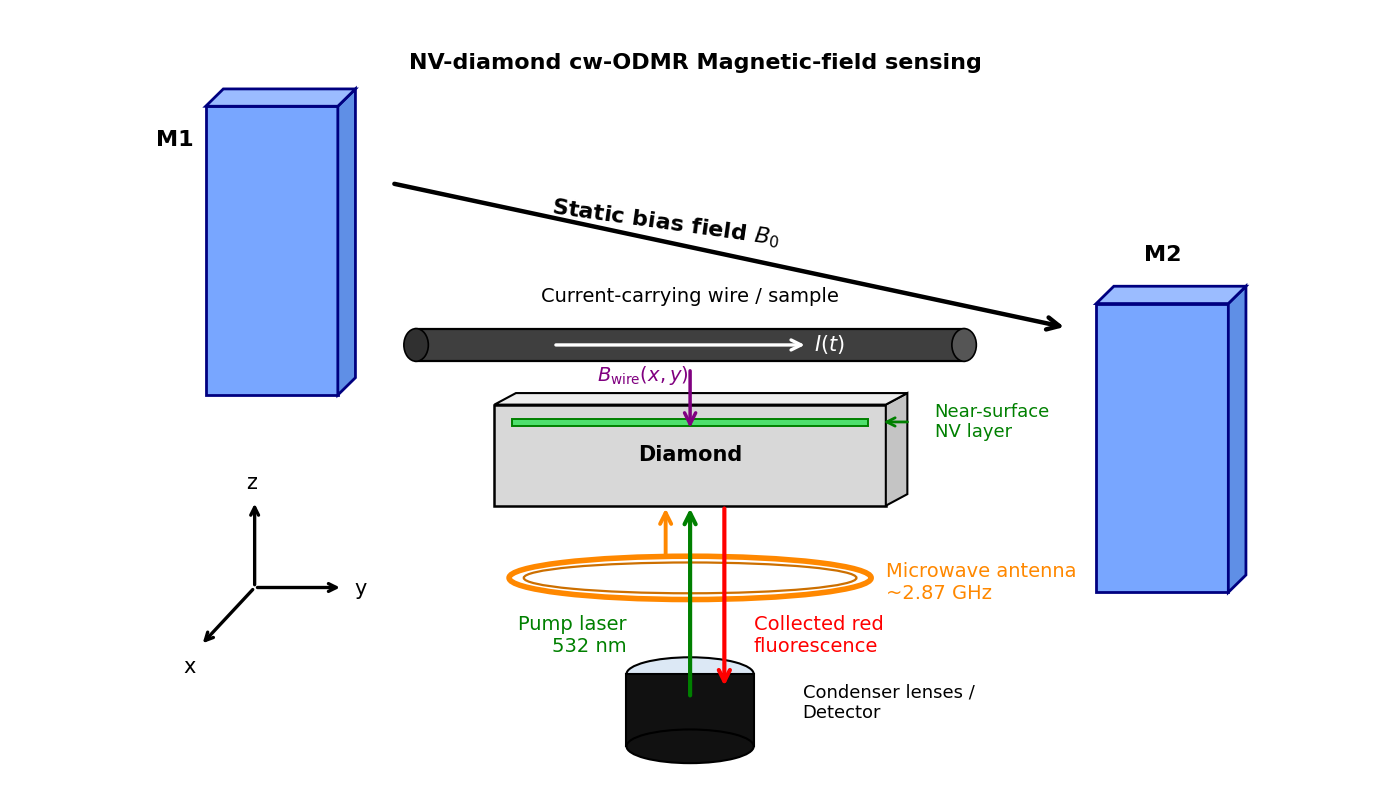

In [41]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Ellipse, Polygon
import matplotlib.patheffects as pe

# ============================================================
# Simple schematic of the NV-diamond magnetometry setup
# Inspired by Troise thesis sensor/optics geometry.
#
# Coordinate convention used in this drawing:
#   z = optical axis, vertical
#   y = horizontal direction from M1 to M2
#   x = depth direction of the setup, drawn diagonally
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")

# ---------- helper functions ----------
def add_3d_box(ax, x, y, w, h, dx=0.18, dy=0.18,
               face="#78a6ff", edge="navy", lw=2):
    """Draw a simple 3D-looking rectangular block."""
    front = Rectangle((x, y), w, h, facecolor=face, edgecolor=edge, lw=lw)
    side = Polygon(
        [[x+w, y], [x+w+dx, y+dy], [x+w+dx, y+h+dy], [x+w, y+h]],
        closed=True, facecolor="#5f8fe6", edgecolor=edge, lw=lw
    )
    top = Polygon(
        [[x, y+h], [x+dx, y+h+dy], [x+w+dx, y+h+dy], [x+w, y+h]],
        closed=True, facecolor="#9bbcff", edgecolor=edge, lw=lw
    )
    ax.add_patch(front)
    ax.add_patch(side)
    ax.add_patch(top)

def arrow(ax, xy1, xy2, color="black", lw=2.5, ms=18, style="->", zorder=5):
    arr = FancyArrowPatch(
        xy1, xy2,
        arrowstyle=style,
        mutation_scale=ms,
        linewidth=lw,
        color=color,
        zorder=zorder
    )
    ax.add_patch(arr)
    return arr

# ---------- bias magnets ----------
# M1 is higher than M2 to indicate an inclined static bias field.
add_3d_box(ax, x=2.0, y=4.0, w=1.35, h=3.0)
ax.text(1.68, 6.55, "M1", ha="center", va="bottom", fontsize=16, fontweight="bold")

add_3d_box(ax, x=11.1, y=1.95, w=1.35, h=3.0)
ax.text(11.78, 5.35, "M2", ha="center", va="bottom", fontsize=16, fontweight="bold")

# Inclined static bias field
arrow(ax, (3.9, 6.2), (10.8, 4.7), color="black", lw=3.2, ms=22)
ax.text(6.7, 5.5, r"Static bias field $B_0$", fontsize=16, fontweight="bold",
        ha="center", va="bottom", rotation=-8)

# ---------- current-carrying wire/sample ----------
wire_y = 4.35
wire_x0 = 4.15
wire_w = 5.6
wire_h = 0.34

# Cylindrical-looking wire: rectangle plus end ellipses
wire = Rectangle((wire_x0, wire_y), wire_w, wire_h,
                 facecolor="#3f3f3f", edgecolor="black", lw=1.6)
ax.add_patch(wire)
ax.add_patch(Ellipse((wire_x0, wire_y + wire_h/2), 0.25, wire_h,
                     facecolor="#303030", edgecolor="black", lw=1.2))
ax.add_patch(Ellipse((wire_x0 + wire_w, wire_y + wire_h/2), 0.25, wire_h,
                     facecolor="#555555", edgecolor="black", lw=1.2))

ax.text(6.95, 4.92, "Current-carrying wire / sample",
        ha="center", va="bottom", fontsize=14)

# Current arrow inside wire
arrow(ax, (5.55, wire_y + wire_h/2), (8.15, wire_y + wire_h/2),
      color="white", lw=2.4, ms=18)
ax.text(8.22, wire_y + wire_h/2, r"$I(t)$", color="white",
        fontsize=15, fontweight="bold", va="center", ha="left")

# Wire-generated magnetic field toward NV layer
arrow(ax, (6.95, 4.28), (6.95, 3.63), color="purple", lw=2.5, ms=20)
ax.text(6.0, 4.2, r"$B_{\mathrm{wire}}(x,y)$",
        color="purple", fontsize=14, ha="left", va="center")

# ---------- diamond plate ----------
diamond_x, diamond_y = 4.95, 2.85
diamond_w, diamond_h = 4.0, 1.05

# 3D-ish diamond body
diamond_front = Rectangle((diamond_x, diamond_y), diamond_w, diamond_h,
                          facecolor="#d8d8d8", edgecolor="black", lw=1.8)
diamond_side = Polygon(
    [[diamond_x+diamond_w, diamond_y],
     [diamond_x+diamond_w+0.22, diamond_y+0.12],
     [diamond_x+diamond_w+0.22, diamond_y+diamond_h+0.12],
     [diamond_x+diamond_w, diamond_y+diamond_h]],
    closed=True, facecolor="#c4c4c4", edgecolor="black", lw=1.5
)
diamond_top = Polygon(
    [[diamond_x, diamond_y+diamond_h],
     [diamond_x+0.22, diamond_y+diamond_h+0.12],
     [diamond_x+diamond_w+0.22, diamond_y+diamond_h+0.12],
     [diamond_x+diamond_w, diamond_y+diamond_h]],
    closed=True, facecolor="#eeeeee", edgecolor="black", lw=1.5
)
ax.add_patch(diamond_front)
ax.add_patch(diamond_side)
ax.add_patch(diamond_top)

ax.text(diamond_x + diamond_w/2, diamond_y + diamond_h/2,
        "Diamond", ha="center", va="center", fontsize=15, fontweight="bold")

# Near-surface NV layer near top of diamond
nv_y = diamond_y + diamond_h - 0.22
nv_layer = Rectangle((diamond_x + 0.18, nv_y), diamond_w - 0.36, 0.07,
                     facecolor="#4ee06d", edgecolor="green", lw=1.4)
ax.add_patch(nv_layer)
ax.text(9.45, nv_y + 0.04, "Near-surface\nNV layer",
        color="green", ha="left", va="center", fontsize=13)
arrow(ax, (9.2, nv_y + 0.04), (diamond_x + diamond_w - 0.05, nv_y + 0.04),
      color="green", lw=2.0, ms=15)

# ---------- optical axis, laser and fluorescence ----------
x_axis = diamond_x + diamond_w/2

# Green pump laser, simplified as vertical upward optical path from below
arrow(ax, (x_axis, 0.85), (x_axis, diamond_y), color="green", lw=3.0, ms=20)
ax.text(x_axis - 0.65, 1.50, "Pump laser\n532 nm",
        color="green", fontsize=14, ha="right", va="center")

# Red fluorescence collected downward on same vertical optical axis
arrow(ax, (x_axis + 0.35, diamond_y), (x_axis + 0.35, 0.95),
      color="red", lw=3.0, ms=20)
ax.text(x_axis + 0.65, 1.50, "Collected red\nfluorescence",
        color="red", fontsize=14, ha="left", va="center")

# Detector / condenser lenses below diamond
det_x, det_y = x_axis - 0.65, 0.35
det_w, det_h = 1.3, 0.75

# Lens top
ax.add_patch(Ellipse((x_axis, det_y + det_h), det_w, 0.35,
                     facecolor="#dce8f5", edgecolor="black", lw=1.5))
# Detector body
ax.add_patch(Rectangle((det_x, det_y), det_w, det_h,
                       facecolor="#111111", edgecolor="black", lw=1.5))
ax.add_patch(Ellipse((x_axis, det_y), det_w, 0.35,
                     facecolor="#111111", edgecolor="black", lw=1.5))
ax.text(x_axis + 1.15, 0.8, "Condenser lenses /\nDetector",
        fontsize=13, ha="left", va="center")

# ---------- microwave antenna / loop ----------
# Draw microwave loop below diamond and above detector.
mw_y = 2.1
ax.add_patch(Ellipse((x_axis, mw_y), 3.7, 0.45,
                     facecolor="none", edgecolor="#ff8800", lw=4))
ax.add_patch(Ellipse((x_axis, mw_y), 3.4, 0.32,
                     facecolor="none", edgecolor="#cc6f00", lw=1.6))

# Microwave delivery arrow upward
arrow(ax, (x_axis - 0.25, mw_y + 0.2), (x_axis - 0.25, diamond_y),
      color="#ff8800", lw=2.8, ms=20)
ax.text(x_axis + 2.0, mw_y - 0.05, "Microwave antenna \n~2.87 GHz",
        color="#ff8800", fontsize=14, ha="left", va="center")

# ---------- coordinate system in corner ----------
origin = (2.5, 2)
# z upward
arrow(ax, origin, (origin[0], origin[1] + 0.9), color="black", lw=2.4, ms=14)
ax.text(origin[0]-0.03, origin[1]+1.02, "z", fontsize=15, ha="center")
# y from M1 to M2
arrow(ax, origin, (origin[0] + 0.9, origin[1]), color="black", lw=2.4, ms=14)
ax.text(origin[0]+1.02, origin[1]-0.02, "y", fontsize=15, va="center")
# x depth direction
arrow(ax, origin, (origin[0] - 0.55, origin[1] - 0.6), color="black", lw=2.4, ms=14)
ax.text(origin[0]-0.66, origin[1]-0.72, "x", fontsize=15, ha="center", va="top")


# ---------- optional title ----------
ax.text(7.0, 7.45, "NV-diamond cw-ODMR Magnetic-field sensing",
        ha="center", va="center", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig("nv_diamond_setup_schematic.png", dpi=300, bbox_inches="tight")
plt.show()

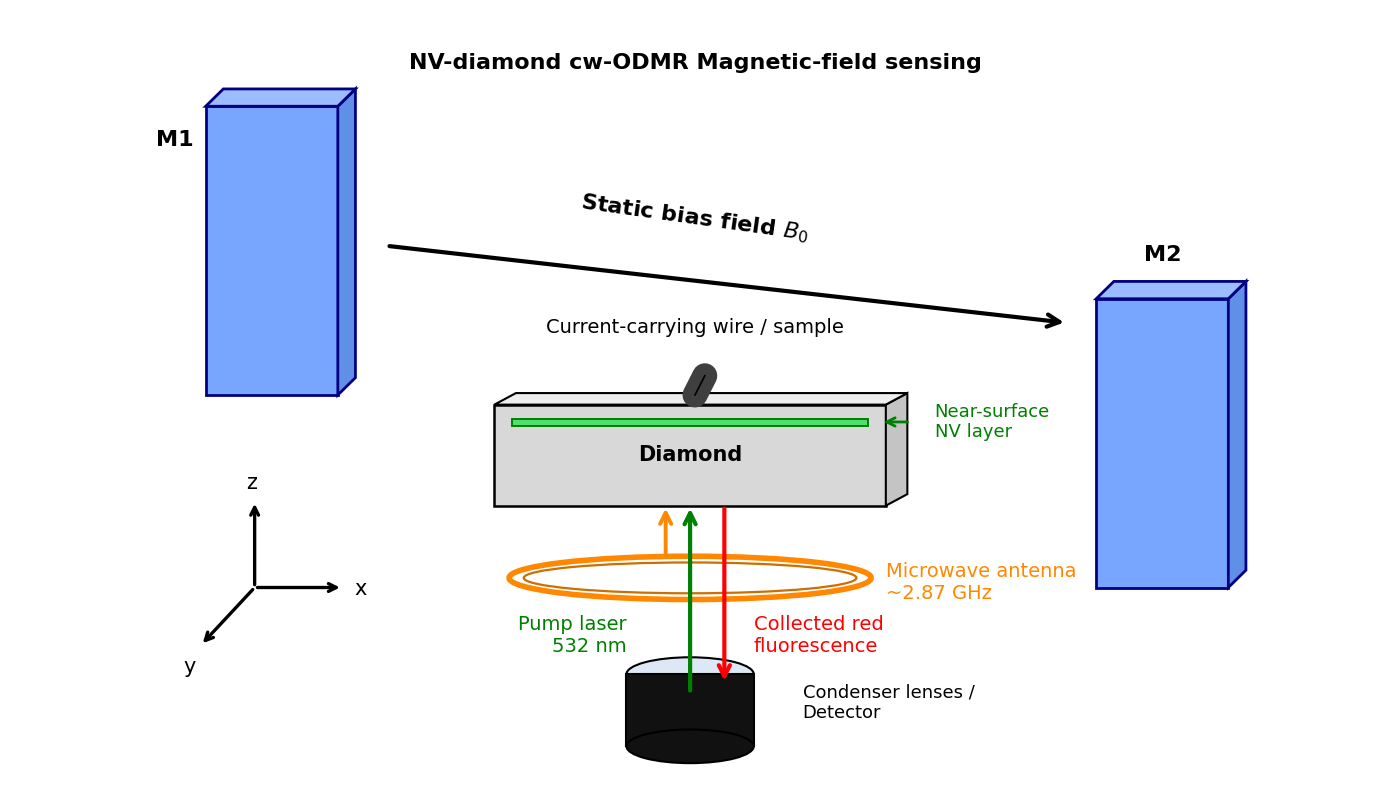

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Ellipse, Polygon

# ============================================================
# Corrected schematic of the NV-diamond magnetometry setup
#
# Corrected coordinate convention:
#   z = optical axis, vertical
#   x = horizontal in-plane direction from M1 to M2
#   y = in-plane depth direction, drawn diagonally
#
# The current-carrying wire is perpendicular to the magnet line,
# so in this convention it is along y.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")

# ---------- helper functions ----------
def add_3d_box(ax, x, y, w, h, dx=0.18, dy=0.18,
               face="#78a6ff", edge="navy", lw=2):
    front = Rectangle((x, y), w, h, facecolor=face, edgecolor=edge, lw=lw)
    side = Polygon(
        [[x+w, y], [x+w+dx, y+dy], [x+w+dx, y+h+dy], [x+w, y+h]],
        closed=True, facecolor="#5f8fe6", edgecolor=edge, lw=lw
    )
    top = Polygon(
        [[x, y+h], [x+dx, y+h+dy], [x+w+dx, y+h+dy], [x+w, y+h]],
        closed=True, facecolor="#9bbcff", edgecolor=edge, lw=lw
    )
    ax.add_patch(front)
    ax.add_patch(side)
    ax.add_patch(top)

def arrow(ax, xy1, xy2, color="black", lw=2.5, ms=18, style="->", zorder=5):
    arr = FancyArrowPatch(
        xy1, xy2,
        arrowstyle=style,
        mutation_scale=ms,
        linewidth=lw,
        color=color,
        zorder=zorder
    )
    ax.add_patch(arr)
    return arr

# ---------- bias magnets ----------
add_3d_box(ax, x=2.0, y=4.0, w=1.35, h=3.0)
ax.text(1.68, 6.55, "M1", ha="center", va="bottom", fontsize=16, fontweight="bold")

add_3d_box(ax, x=11.1, y=2.0, w=1.35, h=3.0)
ax.text(11.78, 5.35, "M2", ha="center", va="bottom", fontsize=16, fontweight="bold")

# Bias field between magnets: now along x (horizontal in-plane)
arrow(ax, (3.85, 5.55), (10.8, 4.75), color="black", lw=3.0, ms=22)
ax.text(7.0, 5.55, r"Static bias field $B_0$", fontsize=16, fontweight="bold",
        ha="center", va="bottom", rotation=-8)

# ---------- current-carrying wire/sample ----------
# Draw it along the corrected y direction (diagonal in the drawing)
wire_start = (7.1, 4.2)
wire_end   = (7.0, 4.0)

ax.plot(
    [wire_start[0], wire_end[0]],
    [wire_start[1], wire_end[1]],
    color="#3f3f3f",
    lw=18,
    solid_capstyle="round",
    zorder=3
)
ax.plot(
    [wire_start[0], wire_end[0]],
    [wire_start[1], wire_end[1]],
    color="black",
    lw=1.2,
    zorder=4
)

ax.text(7.0, 4.6, "Current-carrying wire / sample",
        ha="center", va="bottom", fontsize=14)


# ---------- diamond ----------
diamond_x, diamond_y = 4.95, 2.85
diamond_w, diamond_h = 4.0, 1.05

diamond_front = Rectangle((diamond_x, diamond_y), diamond_w, diamond_h,
                          facecolor="#d8d8d8", edgecolor="black", lw=1.8)
diamond_side = Polygon(
    [[diamond_x+diamond_w, diamond_y],
     [diamond_x+diamond_w+0.22, diamond_y+0.12],
     [diamond_x+diamond_w+0.22, diamond_y+diamond_h+0.12],
     [diamond_x+diamond_w, diamond_y+diamond_h]],
    closed=True, facecolor="#c4c4c4", edgecolor="black", lw=1.5
)
diamond_top = Polygon(
    [[diamond_x, diamond_y+diamond_h],
     [diamond_x+0.22, diamond_y+diamond_h+0.12],
     [diamond_x+diamond_w+0.22, diamond_y+diamond_h+0.12],
     [diamond_x+diamond_w, diamond_y+diamond_h]],
    closed=True, facecolor="#eeeeee", edgecolor="black", lw=1.5
)
ax.add_patch(diamond_front)
ax.add_patch(diamond_side)
ax.add_patch(diamond_top)

ax.text(diamond_x + diamond_w/2, diamond_y + diamond_h/2,
        "Diamond", ha="center", va="center", fontsize=15, fontweight="bold")

# Near-surface NV layer
nv_y = diamond_y + diamond_h - 0.22
nv_layer = Rectangle((diamond_x + 0.18, nv_y), diamond_w - 0.36, 0.07,
                     facecolor="#4ee06d", edgecolor="green", lw=1.4)
ax.add_patch(nv_layer)

ax.text(9.45, nv_y + 0.04, "Near-surface\nNV layer",
        color="green", ha="left", va="center", fontsize=13)
arrow(ax, (9.2, nv_y + 0.04), (diamond_x + diamond_w - 0.05, nv_y + 0.04),
      color="green", lw=2.0, ms=15)

# ---------- optical axis / pump / fluorescence ----------
x_axis = diamond_x + diamond_w/2

# Green pump laser
arrow(ax, (x_axis, 0.9), (x_axis, diamond_y), color="green", lw=3.0, ms=20)
ax.text(x_axis - 0.65, 1.50, "Pump laser\n532 nm",
        color="green", fontsize=14, ha="right", va="center")

# Red fluorescence
arrow(ax, (x_axis + 0.35, diamond_y), (x_axis + 0.35, 1.0),
      color="red", lw=3.0, ms=20)
ax.text(x_axis + 0.65, 1.50, "Collected red\nfluorescence",
        color="red", fontsize=14, ha="left", va="center")

# Detector / condenser
det_x, det_y = x_axis - 0.65, 0.35
det_w, det_h = 1.3, 0.75

ax.add_patch(Ellipse((x_axis, det_y + det_h), det_w, 0.35,
                     facecolor="#dce8f5", edgecolor="black", lw=1.5))
ax.add_patch(Rectangle((det_x, det_y), det_w, det_h,
                       facecolor="#111111", edgecolor="black", lw=1.5))
ax.add_patch(Ellipse((x_axis, det_y), det_w, 0.35,
                     facecolor="#111111", edgecolor="black", lw=1.5))

ax.text(x_axis + 1.15, 0.8, "Condenser lenses /\nDetector",
        fontsize=13, ha="left", va="center")

# ---------- MW antenna ----------
mw_y = 2.1
ax.add_patch(Ellipse((x_axis, mw_y), 3.7, 0.45,
                     facecolor="none", edgecolor="#ff8800", lw=4))
ax.add_patch(Ellipse((x_axis, mw_y), 3.4, 0.32,
                     facecolor="none", edgecolor="#cc6f00", lw=1.6))

arrow(ax, (x_axis - 0.25, mw_y + 0.2), (x_axis - 0.25, diamond_y),
      color="#ff8800", lw=2.8, ms=20)
ax.text(x_axis + 2.0, mw_y - 0.05, "Microwave antenna\n~2.87 GHz",
        color="#ff8800", fontsize=14, ha="left", va="center")

# ---------- coordinate system ----------
origin = (2.5, 2.0)

# z upward
arrow(ax, origin, (origin[0], origin[1] + 0.9), color="black", lw=2.4, ms=14)
ax.text(origin[0]-0.03, origin[1]+1.02, "z", fontsize=15, ha="center")

# x horizontal (M1 -> M2 direction)
arrow(ax, origin, (origin[0] + 0.9, origin[1]), color="black", lw=2.4, ms=14)
ax.text(origin[0]+1.02, origin[1]-0.02, "x", fontsize=15, va="center")

# y diagonal (wire direction)
arrow(ax, origin, (origin[0] - 0.55, origin[1] - 0.6), color="black", lw=2.4, ms=14)
ax.text(origin[0]-0.66, origin[1]-0.72, "y", fontsize=15, ha="center", va="top")

# ---------- title ----------
ax.text(7.0, 7.45, "Simplified schematic of the setup",
        ha="center", va="center", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig("nv_diamond_setup_schematic_corrected.png", dpi=300, bbox_inches="tight")
plt.show()

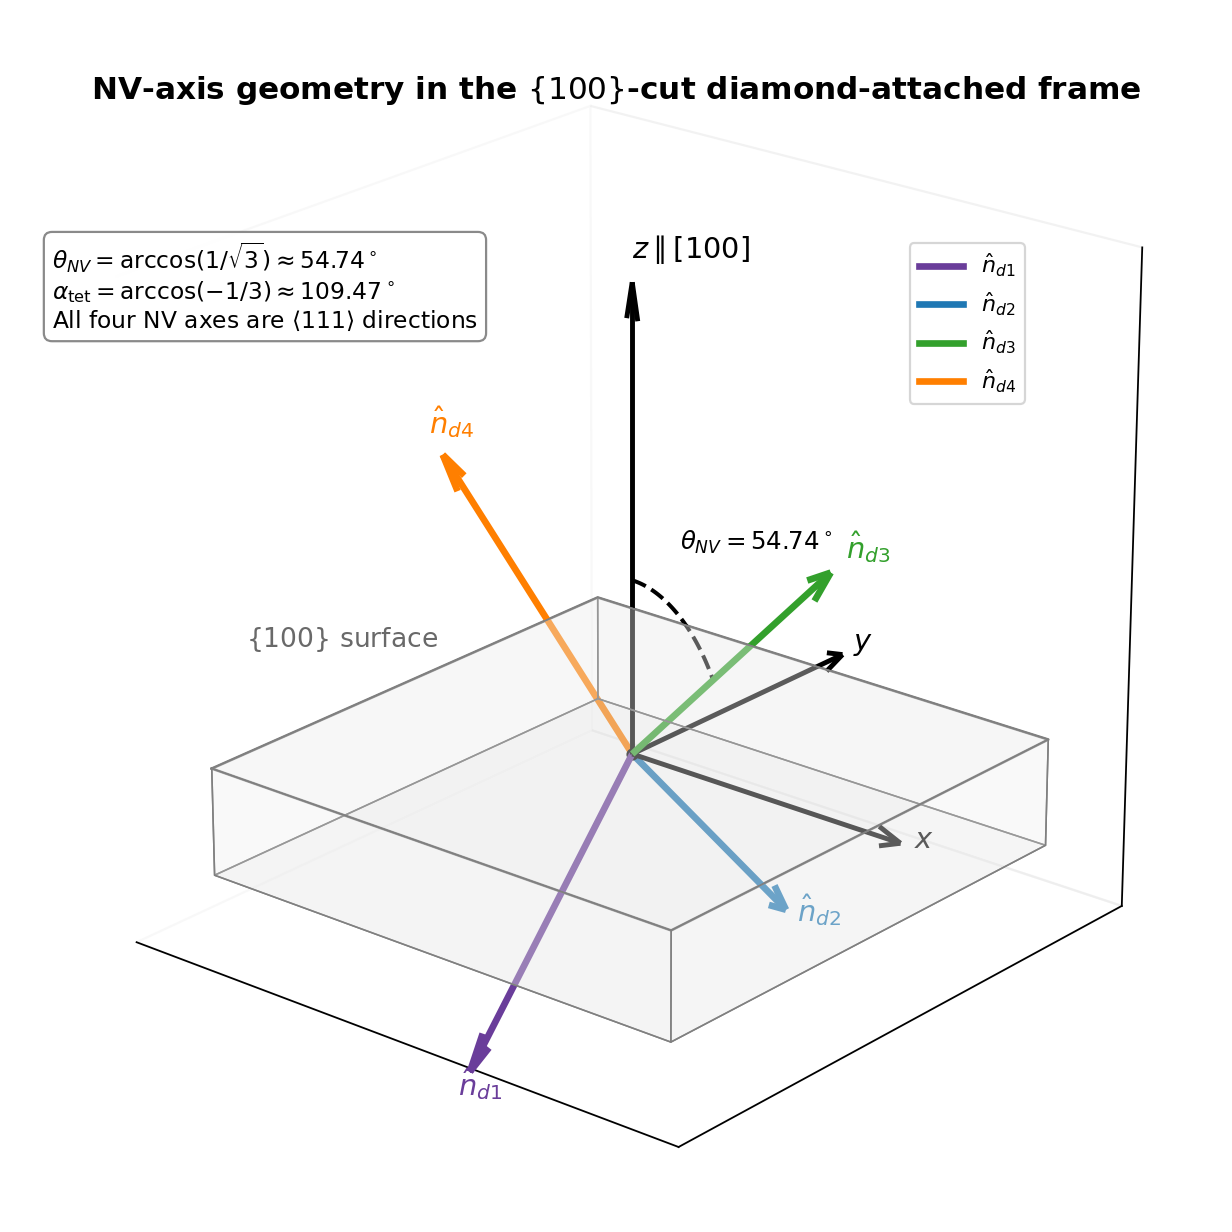

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ============================================================
# NV-axis geometry for a {100}-cut diamond in the chosen lab frame
# z  -> surface normal [100]
# x,y -> in-plane axes chosen to match the dip-to-axis assignment
#
# Axis assignment supplied by the user:
#   d3 = ( +sqrt(2/3),  0, +1/sqrt(3) )
#   d2 = ( 0, +sqrt(2/3), -1/sqrt(3) )
#   d4 = ( -sqrt(2/3), 0, +1/sqrt(3) )
#   d1 = ( 0, -sqrt(2/3), -1/sqrt(3) )
#
# This figure is designed to complement the setup schematic.
# ============================================================

# ---------- NV axes ----------
s23 = np.sqrt(2/3)
s13 = 1/np.sqrt(3)

nv_axes = {
    "d3": np.array([ s23,  0.0,  s13]),
    "d2": np.array([ 0.0,  s23, -s13]),
    "d4": np.array([-s23,  0.0,  s13]),
    "d1": np.array([ 0.0, -s23, -s13]),
}

colors = {
    "d1": "#6a3d9a",  # purple
    "d2": "#1f78b4",  # blue
    "d3": "#33a02c",  # green
    "d4": "#ff7f00",  # orange
}

# ---------- Standard angles ----------
theta_nv_deg = np.degrees(np.arccos(1/np.sqrt(3)))   # 54.7356...
alpha_tet_deg = np.degrees(np.arccos(-1/3))          # 109.4712...

# ---------- Figure ----------
fig = plt.figure(figsize=(8.4, 7.8), dpi=160)
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect([1, 1, 1])

# ---------- Draw a translucent diamond slab ----------
# Top surface = {100} face at z = 0
# Diamond extends slightly to z < 0 for visual context
L = 1.05
z_top = 0.0
z_bot = -0.28

faces = [
    [(-L, -L, z_top), ( L, -L, z_top), ( L,  L, z_top), (-L,  L, z_top)],  # top
    [(-L, -L, z_bot), ( L, -L, z_bot), ( L,  L, z_bot), (-L,  L, z_bot)],  # bottom
    [(-L, -L, z_bot), ( L, -L, z_bot), ( L, -L, z_top), (-L, -L, z_top)],  # front
    [(-L,  L, z_bot), ( L,  L, z_bot), ( L,  L, z_top), (-L,  L, z_top)],  # back
    [(-L, -L, z_bot), (-L,  L, z_bot), (-L,  L, z_top), (-L, -L, z_top)],  # left
    [( L, -L, z_bot), ( L,  L, z_bot), ( L,  L, z_top), ( L, -L, z_top)],  # right
]

slab = Poly3DCollection(
    faces,
    facecolors=["#e8e8e8", "#d9d9d9", "#efefef", "#efefef", "#f4f4f4", "#f4f4f4"],
    edgecolors="gray",
    linewidths=0.7,
    alpha=0.22
)
ax.add_collection3d(slab)

# Outline the top surface a bit stronger
top_outline = np.array([[-L, -L, z_top], [L, -L, z_top], [L, L, z_top], [-L, L, z_top], [-L, -L, z_top]])
ax.plot(top_outline[:,0], top_outline[:,1], top_outline[:,2], color="gray", lw=1.2)

# ---------- Lab axes ----------
axis_len = 1.2
ax.quiver(0, 0, 0, axis_len, 0, 0, color="black", linewidth=2.2, arrow_length_ratio=0.08)
ax.quiver(0, 0, 0, 0, axis_len, 0, color="black", linewidth=2.2, arrow_length_ratio=0.08)
ax.quiver(0, 0, 0, 0, 0, axis_len, color="black", linewidth=2.2, arrow_length_ratio=0.08)

ax.text(axis_len + 0.06, 0, 0, r"$x$", fontsize=13, color="black")
ax.text(0, axis_len + 0.06, 0, r"$y$", fontsize=13, color="black")
ax.text(0, 0, axis_len + 0.06, r"$z\parallel[100]$", fontsize=13, color="black")

# ---------- Plot the four NV axes ----------
arrow_len = 1.08
for name, vec in nv_axes.items():
    v = arrow_len * vec
    ax.quiver(0, 0, 0, v[0], v[1], v[2],
              color=colors[name], linewidth=3.0, arrow_length_ratio=0.10)
    # label near the tip
    offset = 0.08 * vec
    ax.text(v[0] + offset[0], v[1] + offset[1], v[2] + offset[2],
            rf"$\hat n_{{{name}}}$", color=colors[name], fontsize=13, fontweight="bold")

# ---------- Mark the origin / NV location ----------
ax.scatter([0], [0], [0], color="black", s=20)
#ax.text(0.04, 0.04, 0.04, "NV", fontsize=11, color="black")

# ---------- Angle arc for theta_NV in the x-z plane ----------
# Use n_d3 since it lies in the x-z plane
r_arc = 0.45
theta = np.linspace(0, np.arccos(1/np.sqrt(3)), 120)
x_arc = r_arc * np.sin(theta)
y_arc = np.zeros_like(theta)
z_arc = r_arc * np.cos(theta)
ax.plot(x_arc, y_arc, z_arc, color="black", lw=1.8, ls="--")
ax.text(0.3, -0.1, 0.60, rf"$\theta_{{NV}} = {theta_nv_deg:.2f}^\circ$", fontsize=11)

# ---------- Surface annotation ----------
ax.text(0.0, -1.5, 0.6, r"$\{100\}$ surface", fontsize=12, color="dimgray", ha="center")
#ax.text(0.0, -1.22, -0.3, r"(diamond top face)", fontsize=10, color="dimgray", ha="center")

# ---------- Text box with geometry summary ----------
summary = (
    r"$\theta_{NV}=\arccos(1/\sqrt{3})\approx54.74^\circ$" "\n"
    r"$\alpha_{\rm tet}=\arccos(-1/3)\approx109.47^\circ$" "\n"
    r"All four NV axes are $\langle 111\rangle$ directions"
)
ax.text2D(
    0.03, 0.74, summary,
    transform=ax.transAxes,
    fontsize=10.5,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.92, edgecolor="gray")
)

# ---------- Legend ----------
legend_lines = [
    Line2D([0], [0], color=colors["d1"], lw=3, label=r"$\hat n_{d1}$"),
    Line2D([0], [0], color=colors["d2"], lw=3, label=r"$\hat n_{d2}$"),
    Line2D([0], [0], color=colors["d3"], lw=3, label=r"$\hat n_{d3}$"),
    Line2D([0], [0], color=colors["d4"], lw=3, label=r"$\hat n_{d4}$"),
]
ax.legend(handles=legend_lines, loc="upper right", bbox_to_anchor=(0.85, 0.82), frameon=True)

# ---------- Formatting ----------
ax.set_title(r"NV-axis geometry in the $\{100\}$-cut diamond-attached frame",
             y=1, fontsize=14, fontweight="bold")

ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_zlim(-0.45, 1.25)

# Clean look
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(False)
ax.view_init(elev=22, azim=-50)

plt.tight_layout()
plt.show()

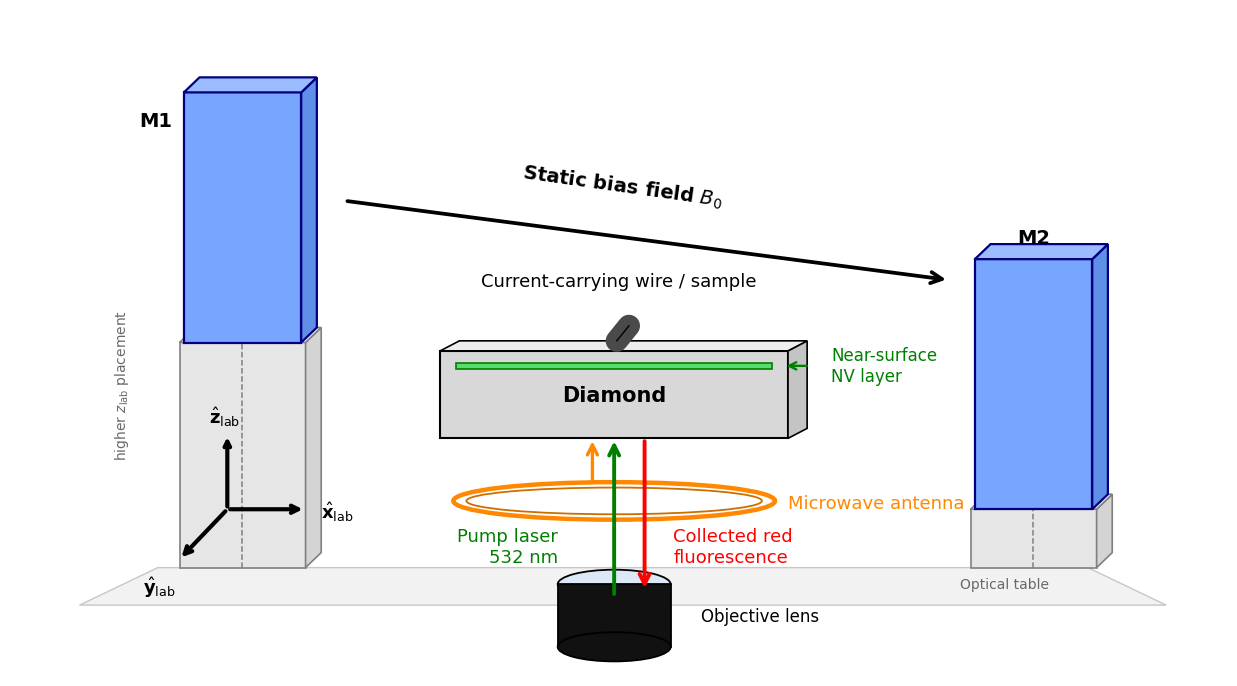

In [41]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Ellipse, Polygon

# ============================================================
# Report-style schematic of the NV-diamond magnetometry setup
# Lab-frame convention:
#   z_lab : optical axis (vertical)
#   x_lab : horizontal in-plane direction (M1 -> M2)
#   y_lab : in-plane depth direction (drawn diagonally)
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "font.family": "sans-serif"
})

fig, ax = plt.subplots(figsize=(12.5, 7.0))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_facecolor("white")


# ---------- helper functions ----------
def add_3d_box(ax, x, y, w, h, dx=0.18, dy=0.18,
               face="#78a6ff", side="#5f8fe6", top="#9bbcff",
               edge="navy", lw=1.6, zorder=3):
    front = Rectangle((x, y), w, h, facecolor=face, edgecolor=edge, lw=lw, zorder=zorder)
    side_patch = Polygon(
        [[x+w, y], [x+w+dx, y+dy], [x+w+dx, y+h+dy], [x+w, y+h]],
        closed=True, facecolor=side, edgecolor=edge, lw=lw, zorder=zorder
    )
    top_patch = Polygon(
        [[x, y+h], [x+dx, y+h+dy], [x+w+dx, y+h+dy], [x+w, y+h]],
        closed=True, facecolor=top, edgecolor=edge, lw=lw, zorder=zorder
    )
    ax.add_patch(front)
    ax.add_patch(side_patch)
    ax.add_patch(top_patch)


def arrow(ax, xy1, xy2, color="black", lw=2.2, ms=16, style="->", zorder=5):
    arr = FancyArrowPatch(
        xy1, xy2,
        arrowstyle=style,
        mutation_scale=ms,
        linewidth=lw,
        color=color,
        zorder=zorder
    )
    ax.add_patch(arr)
    return arr


# ============================================================
# Floor / optical table plane
# ============================================================
floor = Polygon(
    [(0.8, 0.85), (13.3, 0.85), (12.4, 1.30), (1.7, 1.30)],
    closed=True,
    facecolor="#f2f2f2",
    edgecolor="#c7c7c7",
    lw=1.0,
    zorder=0
)
ax.add_patch(floor)

ax.text(12, 1.10, "Optical table ",
        fontsize=10, color="dimgray", ha="right", va="center")


# ============================================================
# Magnet pedestals to show different mounting heights
# ============================================================
# M1 pedestal (taller)
add_3d_box(
    ax, x=1.95, y=1.30, w=1.45, h=2.70,
    face="#e6e6e6", side="#d4d4d4", top="#f2f2f2",
    edge="gray", lw=1.2, zorder=1
)

# M2 pedestal (shorter)
add_3d_box(
    ax, x=11.05, y=1.30, w=1.45, h=0.70,
    face="#e6e6e6", side="#d4d4d4", top="#f2f2f2",
    edge="gray", lw=1.2, zorder=1
)


# ============================================================
# Bias magnets
# ============================================================
add_3d_box(ax, x=2.0, y=4.0, w=1.35, h=3.0, zorder=3)
ax.text(1.68, 6.55, "M1", ha="center", va="bottom", fontsize=14, fontweight="bold")

add_3d_box(ax, x=11.1, y=2.0, w=1.35, h=3.0, zorder=3)
ax.text(11.78, 5.15, "M2", ha="center", va="bottom", fontsize=14, fontweight="bold")

# Optional dashed guide lines to the floor
ax.plot([2.67, 2.67], [1.30, 4.00], ls="--", lw=1.1, color="gray", zorder=1)
ax.plot([11.77, 11.77], [1.30, 2.00], ls="--", lw=1.1, color="gray", zorder=1)

# Optional height annotation
ax.text(1.18, 2.65, r"higher $z_{\mathrm{lab}}$ placement", fontsize=10, color="dimgray", rotation=90)


# ============================================================
# Static bias field
# ============================================================
arrow(ax, (3.85, 5.7), (10.8, 4.75), color="black", lw=2.7, ms=20)
ax.text(7.05, 5.58, r"Static bias field $B_0$",
        fontsize=14, fontweight="bold",
        ha="center", va="bottom", rotation=-8)


# ============================================================
# Current-carrying wire / sample
# ============================================================
wire_start = (7.12, 4.20)
wire_end   = (6.98, 4.02)

ax.plot(
    [wire_start[0], wire_end[0]],
    [wire_start[1], wire_end[1]],
    color="#4a4a4a",
    lw=16,
    solid_capstyle="round",
    zorder=4
)
ax.plot(
    [wire_start[0], wire_end[0]],
    [wire_start[1], wire_end[1]],
    color="black",
    lw=1.0,
    zorder=5
)

ax.text(7.0, 4.63, "Current-carrying wire / sample",
        ha="center", va="bottom", fontsize=13)


# ============================================================
# Diamond
# ============================================================
diamond_x, diamond_y = 4.95, 2.85
diamond_w, diamond_h = 4.0, 1.05

diamond_front = Rectangle((diamond_x, diamond_y), diamond_w, diamond_h,
                          facecolor="#d8d8d8", edgecolor="black", lw=1.5, zorder=3)
diamond_side = Polygon(
    [[diamond_x+diamond_w, diamond_y],
     [diamond_x+diamond_w+0.22, diamond_y+0.12],
     [diamond_x+diamond_w+0.22, diamond_y+diamond_h+0.12],
     [diamond_x+diamond_w, diamond_y+diamond_h]],
    closed=True, facecolor="#c4c4c4", edgecolor="black", lw=1.2, zorder=3
)
diamond_top = Polygon(
    [[diamond_x, diamond_y+diamond_h],
     [diamond_x+0.22, diamond_y+diamond_h+0.12],
     [diamond_x+diamond_w+0.22, diamond_y+diamond_h+0.12],
     [diamond_x+diamond_w, diamond_y+diamond_h]],
    closed=True, facecolor="#eeeeee", edgecolor="black", lw=1.2, zorder=3
)

ax.add_patch(diamond_front)
ax.add_patch(diamond_side)
ax.add_patch(diamond_top)

ax.text(diamond_x + diamond_w/2, diamond_y + diamond_h/2,
        "Diamond", ha="center", va="center", fontsize=15, fontweight="bold")


# Near-surface NV layer
nv_y = diamond_y + diamond_h - 0.22
nv_layer = Rectangle((diamond_x + 0.18, nv_y), diamond_w - 0.36, 0.07,
                     facecolor="#59db71", edgecolor="green", lw=1.2, zorder=4)
ax.add_patch(nv_layer)

ax.text(9.45, nv_y + 0.04, "Near-surface\nNV layer",
        color="green", ha="left", va="center", fontsize=12)
arrow(ax, (9.2, nv_y + 0.04), (diamond_x + diamond_w - 0.05, nv_y + 0.04),
      color="green", lw=1.7, ms=13)


# ============================================================
# Optical axis / pump / fluorescence
# ============================================================
x_axis = diamond_x + diamond_w/2

# Pump laser
arrow(ax, (x_axis, 0.95), (x_axis, diamond_y), color="green", lw=2.8, ms=18)
ax.text(x_axis - 0.65, 1.55, "Pump laser\n532 nm",
        color="green", fontsize=13, ha="right", va="center")

# Fluorescence
arrow(ax, (x_axis + 0.35, diamond_y), (x_axis + 0.35, 1.02),
      color="red", lw=2.8, ms=18)
ax.text(x_axis + 0.68, 1.55, "Collected red\nfluorescence",
        color="red", fontsize=13, ha="left", va="center")


# Detector / condenser
det_x, det_y = x_axis - 0.65, 0.35
det_w, det_h = 1.3, 0.75

ax.add_patch(Ellipse((x_axis, det_y + det_h), det_w, 0.35,
                     facecolor="#dce8f5", edgecolor="black", lw=1.3, zorder=2))
ax.add_patch(Rectangle((det_x, det_y), det_w, det_h,
                       facecolor="#111111", edgecolor="black", lw=1.3, zorder=2))
ax.add_patch(Ellipse((x_axis, det_y), det_w, 0.35,
                     facecolor="#111111", edgecolor="black", lw=1.3, zorder=2))

ax.text(x_axis + 1, 0.72, "Objective lens",
        fontsize=12, ha="left", va="center")


# ============================================================
# MW antenna
# ============================================================
mw_y = 2.10
ax.add_patch(Ellipse((x_axis, mw_y), 3.7, 0.45,
                     facecolor="none", edgecolor="#ff8800", lw=3.2, zorder=2))
ax.add_patch(Ellipse((x_axis, mw_y), 3.4, 0.32,
                     facecolor="none", edgecolor="#cc6f00", lw=1.3, zorder=2))

arrow(ax, (x_axis - 0.25, mw_y + 0.2), (x_axis - 0.25, diamond_y),
      color="#ff8800", lw=2.4, ms=18)
ax.text(x_axis + 2.0, mw_y - 0.02, "Microwave antenna",
        color="#ff8800", fontsize=13, ha="left", va="center")


# ============================================================
# Coordinate system: lab frame with vector notation
# ============================================================
origin = (2.5, 2.0)

# z_lab upward
arrow(ax, origin, (origin[0], origin[1] + 0.9), color="black", lw=3, ms=10)
ax.text(origin[0]-0.03, origin[1]+1.04,
        r"$\hat{\mathbf{z}}_{\mathrm{lab}}$",
        fontsize=13, ha="center")

# x_lab horizontal
arrow(ax, origin, (origin[0] + 0.9, origin[1]), color="black", lw=3, ms=13)
ax.text(origin[0]+1.08, origin[1]-0.02,
        r"$\hat{\mathbf{x}}_{\mathrm{lab}}$",
        fontsize=13, va="center", ha="left")

# y_lab diagonal
arrow(ax, origin, (origin[0] - 0.55, origin[1] - 0.6), color="black", lw=3, ms=13)
ax.text(origin[0]-0.78, origin[1]-0.78,
        r"$\hat{\mathbf{y}}_{\mathrm{lab}}$",
        fontsize=13, ha="center", va="top")

plt.tight_layout()
plt.savefig("nv_diamond_setup_schematic_report_style.png", dpi=300, bbox_inches="tight")
plt.show()